In [35]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Create a models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cpu


In [36]:
# 1. Load Data (Use the new realistic dataset)
df = pd.read_csv("../data/profiler_10k_fixed.csv")

# 2. Input (X) and Output (y)
X = df[['Layers', 'Input_Dim', 'Hidden_Dim', 'Params', 'FLOPs']].values
y = df['RAM_MB'].values.reshape(-1, 1)
# 3. Split 60/20/20
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Scale Data (Crucial for Neural Networks)
scaler_x = StandardScaler()
scaler_y = MinMaxScaler() # Normalize target RAM to 0-1 for stability

X_train = scaler_x.fit_transform(X_train_raw)
X_val = scaler_x.transform(X_val_raw)
X_test = scaler_x.transform(X_test_raw)

y_train = scaler_y.fit_transform(y_train_raw)
y_val = scaler_y.transform(y_val_raw)
y_test = scaler_y.transform(y_test_raw)

# 5. Convert to PyTorch Tensors
train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("✅ Data Processed & Loaders Ready")

✅ Data Processed & Loaders Ready


In [37]:
import torch
import torch.nn as nn
import torch.optim as optim

# Make sure device is defined in this cell too just in case
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ProfilerNN(nn.Module):
    def __init__(self):
        super(ProfilerNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 128),      # Updated to 5 inputs
            nn.BatchNorm1d(128),    # Added Batch Normalization for stability
            nn.ReLU(),
            nn.Dropout(0.1),        # Reduced dropout from 0.2 to 0.1
            
            nn.Linear(128, 64),     # Added a middle layer
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1)        # Output: RAM
        )
        
    def forward(self, x):
        return self.net(x)

model = ProfilerNN().to(device)
criterion = nn.MSELoss()

# REDUCED learning rate from 0.001 to 0.0005 so it learns more carefully
optimizer = optim.Adam(model.parameters(), lr=0.0005) 

print("✅ Upgraded Model Architecture Created")

✅ Upgraded Model Architecture Created


In [ ]:
num_epochs = 200 
train_losses = []
val_losses = []

# --- EARLY STOPPING SETTINGS ---
patience = 15  
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_path = '../models/1_architecture_profiler_model.pth'

print("🚀 Starting Training with Early Stopping...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    # Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()
            
    # Record avg losses
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # --- EARLY STOPPING LOGIC ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save the best model right now
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1
        
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{num_epochs} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f} | Patience: {epochs_no_improve}/{patience}")

    if epochs_no_improve >= patience:
        print(f"\n🛑 Early stopping triggered at Epoch {epoch+1}! Model stopped improving.")
        break # Stops the training loop!

print("\n✅ Training Complete. Loading the best model weights...")
model.load_state_dict(torch.load(best_model_path)) # Load the best version back into memory

🚀 Starting Training with Early Stopping...
Epoch 005/200 | Train Loss: 0.00307 | Val Loss: 0.00214 | Patience: 1/15
Epoch 010/200 | Train Loss: 0.00294 | Val Loss: 0.00206 | Patience: 3/15
Epoch 015/200 | Train Loss: 0.00258 | Val Loss: 0.00199 | Patience: 8/15
Epoch 020/200 | Train Loss: 0.00246 | Val Loss: 0.00201 | Patience: 2/15
Epoch 025/200 | Train Loss: 0.00245 | Val Loss: 0.00191 | Patience: 7/15
Epoch 030/200 | Train Loss: 0.00240 | Val Loss: 0.00192 | Patience: 12/15

🛑 Early stopping triggered at Epoch 33! Model stopped improving.

✅ Training Complete. Loading the best model weights...


<All keys matched successfully>

📊 ARCHITECTURE PROFILER METRICS
R2 Score (Accuracy fit): 0.9328
MAE (Avg Error):         16.5535 MB
RMSE (Spike Error):      20.4761 MB
MSE:                     419.2701


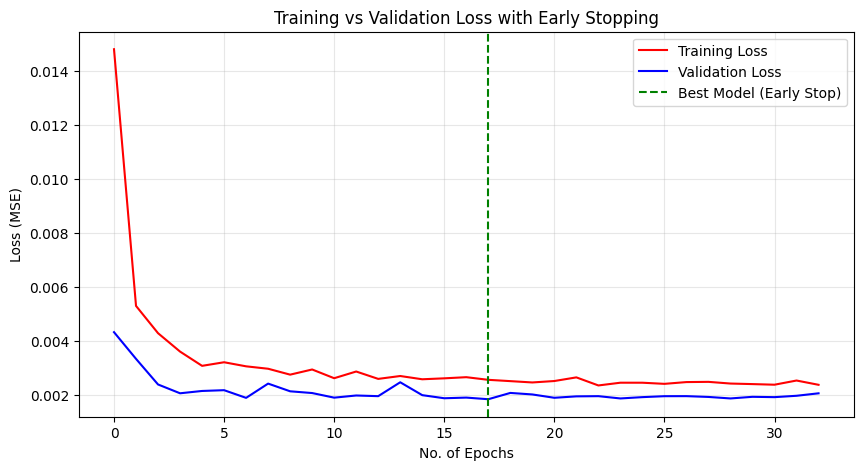

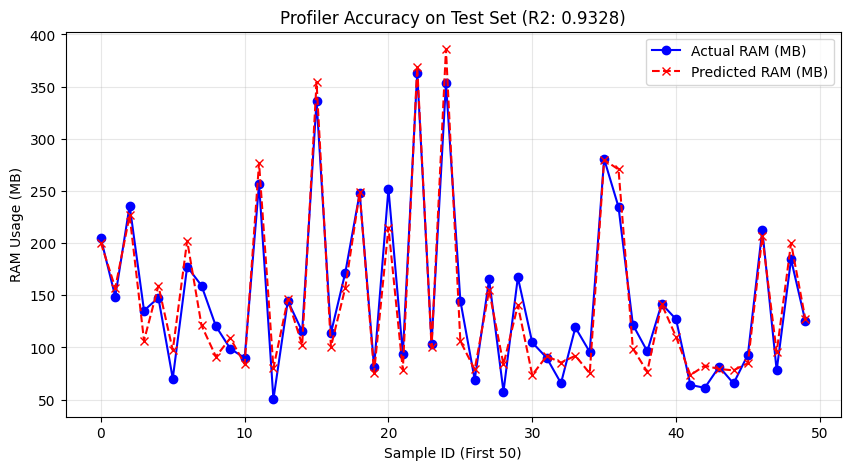

✅ Scalers saved successfully.


In [40]:
# --- 4. EVALUATION & GRAPHS ---
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

model.eval()
with torch.no_grad():
    test_inputs = torch.FloatTensor(X_test).to(device)
    preds = model(test_inputs).cpu().numpy()

# Inverse transform to get actual Megabytes
preds_mb = scaler_y.inverse_transform(preds)
actual_mb = scaler_y.inverse_transform(y_test)

# Calculate Metrics
r2 = r2_score(actual_mb, preds_mb)
mse = mean_squared_error(actual_mb, preds_mb)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_mb, preds_mb)

# Print Formatted Output
print("=============================================")
print("📊 ARCHITECTURE PROFILER METRICS")
print("=============================================")
print(f"R2 Score (Accuracy fit): {r2:.4f}")
print(f"MAE (Avg Error):         {mae:.4f} MB")
print(f"RMSE (Spike Error):      {rmse:.4f} MB")
print(f"MSE:                     {mse:.4f}")
print("=============================================")

# Graph 1: Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='red')
plt.plot(val_losses, label='Validation Loss', color='blue')
if epochs_no_improve >= patience:
    plt.axvline(x=len(train_losses) - patience - 1, color='green', linestyle='--', label='Best Model (Early Stop)')
plt.xlabel('No. of Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss with Early Stopping')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Graph 2: Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(actual_mb[:50], label='Actual RAM (MB)', color='blue', marker='o')
plt.plot(preds_mb[:50], label='Predicted RAM (MB)', color='red', linestyle='--', marker='x')
plt.title(f'Profiler Accuracy on Test Set (R2: {r2:.4f})')
plt.ylabel('RAM Usage (MB)')
plt.xlabel('Sample ID (First 50)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save Scalers
joblib.dump(scaler_x, '../models/1_architecture_profiler_scaler_x.pkl')
joblib.dump(scaler_y, '../models/1_architecture_profiler_scaler_y.pkl')
print("✅ Scalers saved successfully.")

In [42]:
# --- 5. INDEPENDENT TEST ---
print(" RUNNING FINAL INDEPENDENT TEST...")

# Simulate 5 real-world models: [Layers, Input_Dim, Hidden_Dim, Params, FLOPs]
test_cases = np.array([
    [18,  224,  64,  1_200_000,   800_000_000],    # Small (MobileNet)
    [50,  224,  256, 25_000_000,  4_000_000_000],  # Medium (ResNet50)
    [12,  512,  768, 110_000_000, 15_000_000_000], # Large (BERT Base)
    [5,   32,   32,  500_000,     200_000_000],    # Tiny
    [100, 128,  128, 60_000_000,  8_000_000_000]   # Deep but thin
])

test_cases_scaled = scaler_x.transform(test_cases)
inputs_tensor = torch.FloatTensor(test_cases_scaled).to(device)

model.eval()
with torch.no_grad():
    predictions = model(inputs_tensor).cpu().numpy()

predicted_ram = scaler_y.inverse_transform(predictions)

print(f"\n{'TEST CASE':<15} | {'PARAMS':<12} | {'LAYERS':<8} | {'PREDICTED RAM (MB)':<20}")
print("-" * 65)
names = ["MobileNet-ish", "ResNet50-ish", "BERT-ish", "TinyNet", "DeepNet"]

for i, name in enumerate(names):
    params = test_cases[i][3]
    layers = int(test_cases[i][0])
    ram = predicted_ram[i][0]
    print(f"{name:<15} | {params/1e6:.1f}M{'':<5} | {layers:<8} | {ram:.2f} MB")
print("-" * 65)

 RUNNING FINAL INDEPENDENT TEST...

TEST CASE       | PARAMS       | LAYERS   | PREDICTED RAM (MB)  
-----------------------------------------------------------------
MobileNet-ish   | 1.2M      | 18       | 225.32 MB
ResNet50-ish    | 25.0M      | 50       | 751.30 MB
BERT-ish        | 110.0M      | 12       | 2374.33 MB
TinyNet         | 0.5M      | 5        | 93.51 MB
DeepNet         | 60.0M      | 100      | 1383.72 MB
-----------------------------------------------------------------
